Penguins is a dataset containing information about different penguins, such as their bill size, flipper length, body weight, and species.

In [1]:
import seaborn as sns

df = sns.load_dataset("penguins")

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [2]:
df.shape

(344, 7)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


In [4]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [5]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [6]:
X = df[[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]]

In [7]:
X.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0


In [8]:
X.isnull().sum()

bill_length_mm       2
bill_depth_mm        2
flipper_length_mm    2
body_mass_g          2
dtype: int64

In [9]:
X = X.fillna(X.median())

In [10]:
X.isnull().sum()

bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64

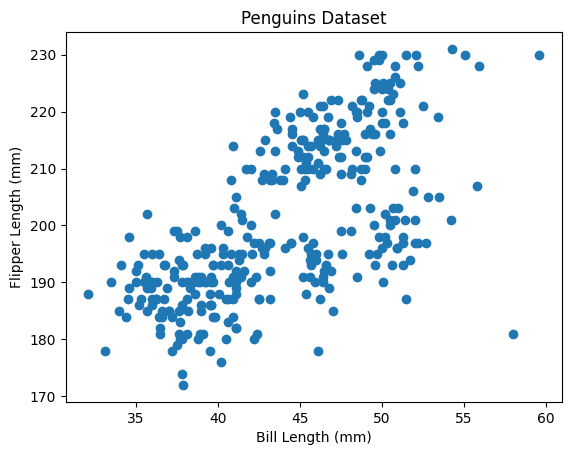

In [11]:
import matplotlib.pyplot as plt

plt.scatter(X["bill_length_mm"], X["flipper_length_mm"])

plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.title("Penguins Dataset")

plt.show()

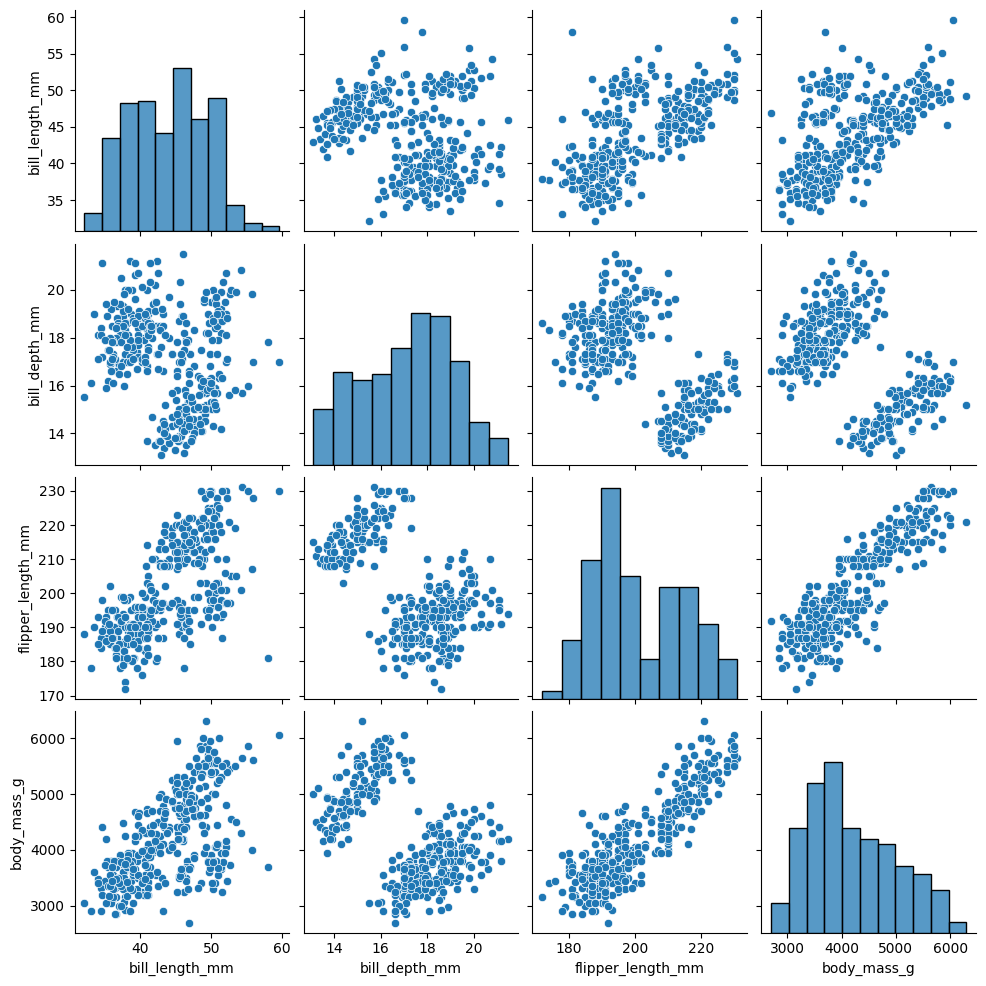

In [12]:
sns.pairplot(X)

plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()  # dimesionlaity reduction

X_scaled = scaler.fit_transform(X)

In [14]:
X_scaled[:5]

array([[-0.88762183,  0.78728939, -1.4205409 , -0.56462526],
       [-0.8140366 ,  0.12611415, -1.06348546, -0.50201047],
       [-0.66686614,  0.43127195, -0.42078568, -1.1907732 ],
       [ 0.09658061,  0.07525452, -0.2779635 , -0.1889365 ],
       [-1.32913321,  1.09244719, -0.56360785, -0.94031402]])

WCSS - within clster sum of square (WCSS)
-foundational metric -k evalaute 

In [15]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

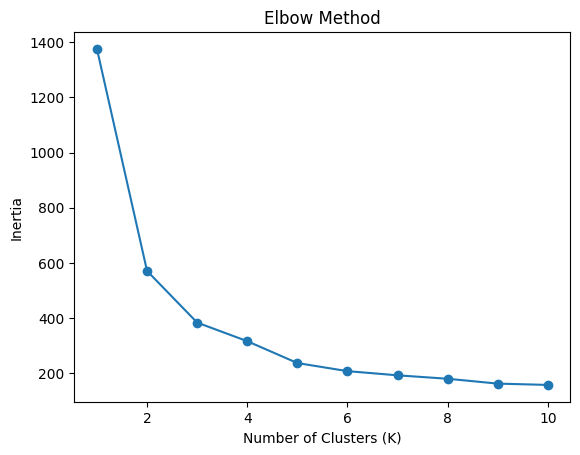

In [16]:
plt.plot(range(1, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

Small dataset → start with K = 1 to 10 → plot inertia → find the elbow → choose K around the elbow → validate with silhouette score.

range(2,11) - silhoutee score -2 cluster 
-cohesion(alpha)-average distance to other points inside its own clusters
-seperation(beta)-average distance to points in the nearest neigbouring cluster

In [17]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

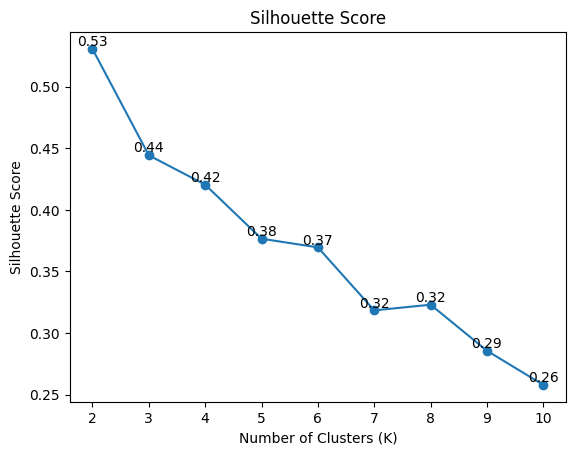

In [18]:
plt.plot(range(2, 11), silhouette_scores, marker="o")

for k, score in zip(range(2, 11), silhouette_scores):
    plt.text(k, score, f"{score:.2f}", ha="center", va="bottom")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()

In [19]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.531
K = 3, Silhouette Score = 0.444
K = 4, Silhouette Score = 0.420
K = 5, Silhouette Score = 0.377
K = 6, Silhouette Score = 0.369
K = 7, Silhouette Score = 0.318
K = 8, Silhouette Score = 0.323
K = 9, Silhouette Score = 0.286
K = 10, Silhouette Score = 0.258


Elbow Method
      ↓
Look for the elbow

Silhouette Score
      ↓
Look for a relatively high score

      ↓
Compare both
      ↓
Choose a reasonable K

In [20]:
kmeans = KMeans(n_clusters=2, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

In [21]:
df["Cluster"] = clusters

In [22]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,Cluster
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,0
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,0


In [23]:
df.tail()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,Cluster
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN,0
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female,1
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male,1
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female,1
343,Gentoo,Biscoe,49.9,16.1,213.0,5400.0,Male,1


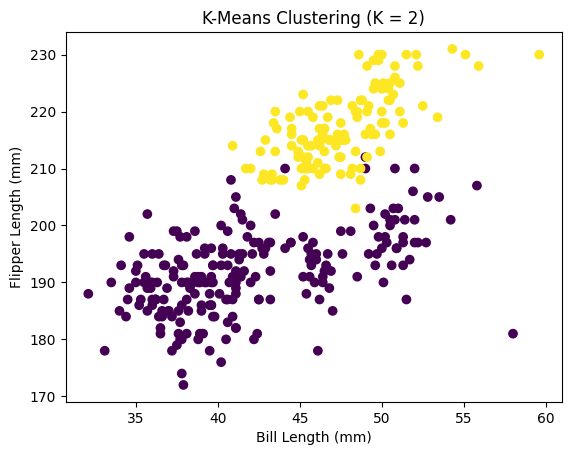

In [24]:
plt.scatter(
    X["bill_length_mm"],
    X["flipper_length_mm"],
    c=clusters
)

plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.title("K-Means Clustering (K = 2)")

plt.show()

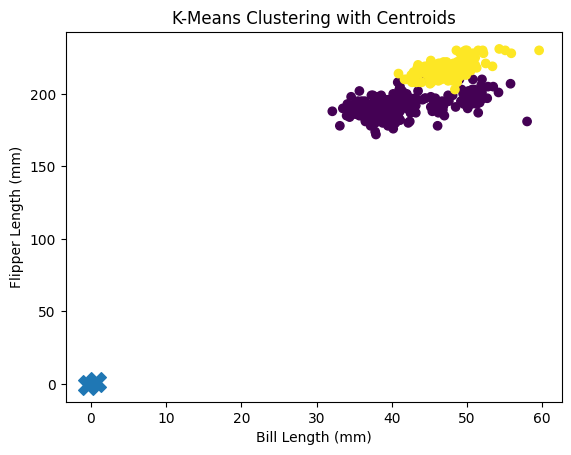

In [25]:
centers = kmeans.cluster_centers_

plt.scatter(
    X["bill_length_mm"],
    X["flipper_length_mm"],
    c=clusters
)

plt.scatter(
    centers[:, 0],
    centers[:, 2],
    marker="X",
    s=200
)

plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.title("K-Means Clustering with Centroids")

plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_15064\721075287.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


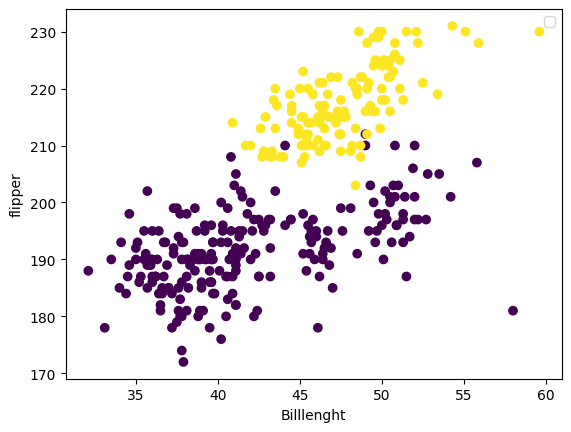

In [28]:
plt.scatter(
    X["bill_length_mm"],
    X["flipper_length_mm"],
    c=clusters
)

plt.xlabel("Billlenght")
plt.ylabel("flipper")
plt.legend()
plt.show()

In [32]:
df[['species',"bill_length_mm","flipper_length_mm","Cluster"]].head(100)

,species,bill_length_mm,flipper_length_mm,Cluster
0,Adelie,39.1,181.0,0
1,Adelie,39.5,186.0,0
2,Adelie,40.3,195.0,0
3,Adelie,NaN,NaN,0
4,Adelie,36.7,193.0,0
...,...,...,...,...
95,Adelie,40.8,208.0,0
96,Adelie,38.1,190.0,0
97,Adelie,40.3,196.0,0
98,Adelie,33.1,178.0,0


1. Load Penguins dataset
        ↓
2. Understand dataset
   shape / info / describe
        ↓
3. Check missing values
        ↓
4. Select numerical features
   bill_length
   bill_depth
   flipper_length
   body_mass
        ↓
5. Visualize the data
        ↓
6. Handle missing values
   Median imputation
        ↓
7. Standardize features
   StandardScaler
        ↓
8. Elbow Method
   Test K = 1 → 10
        ↓
9. Silhouette Score
   Test K = 2 → 10
        ↓
10. Select K = 2
        ↓
11. Apply K-Means
        ↓
12. Assign clusters
        ↓
13. Visualize clusters

In [ ]:
import joblib

joblib.dump(kmeans, "penguins_kmeans.joblib")

['penguins_kmeans.joblib']

In [ ]:
joblib.dump(scaler, "penguins_scaler.joblib")

['penguins_scaler.joblib']

In [ ]:
kmeans_model = joblib.load("penguins_kmeans.joblib")
scaler_model = joblib.load("penguins_scaler.joblib")

In [ ]:
new_penguin = [[45.0, 17.0, 195.0, 4000]]

''' 1. bill_length_mm
2. bill_depth_mm
3. flipper_length_mm
4. body_mass_g'''

In [ ]:
new_penguin_scaled = scaler_model.transform(new_penguin)

c:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
prediction = kmeans_model.predict(new_penguin_scaled)

print("Predicted Cluster:", prediction[0])

Predicted Cluster: 0


Which cluster does this new penguin belong to based on its similarity to the clusters K-Means learned

                 K-Means
                    ↓
          4 features of penguins
                    ↓
             Find 2 centroids
               /          \
              /            \
       Cluster 0          Cluster 1